# Time to 3D rendering + Optical Flow comparison (skimage version)

**Pipeline:**
1. Read echocardiography video → grayscale volume `(T, H, W)`
2. Run **skimage Marching Cubes** → iso-surface mesh
3. Render interactive 3D view with **Plotly**
4. **5 optical flow methods** benchmarked head-to-head:

| | Method | Type | cv2 API |
|---|---|---|---|
| A | MC spatio-temporal gradient | 3D sparse (surface only) | skimage normals |
| B | Farneback | 2D dense | `calcOpticalFlowFarneback` |
| C | Lucas-Kanade sparse | 2D sparse (corners) | `calcOpticalFlowPyrLK` |
| D | DIS — Dense Inverse Search | 2D dense | `DISOpticalFlow` |
| E | RLOF — Robust Local Optical Flow | 2D dense | `calcOpticalFlowSparseRLOF` / `DenseRLOFOpticalFlow` |

Dependencies: `pip install scikit-image opencv-contrib-python plotly numpy pandas`  
*(RLOF requires `opencv-contrib-python`, not the base `opencv-python`)*

## 1 · Load video

In [71]:
import os

# ── Repository path configuration ──────────────────────────────────────────────
# Set BASE_DIR to the root of the EchoCardiographyTo3D repository.
# Default: parent of the 'code/' folder (i.e. the repo root).
BASE_DIR   = os.path.dirname(os.path.abspath('__file__'))  # .../code/
BASE_DIR   = os.path.join(BASE_DIR, '..')                  # repo root
VIDEO_DIR  = os.path.join(BASE_DIR, 'video')
HTML_DIR   = os.path.join(BASE_DIR, 'html')
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
os.makedirs(HTML_DIR,   exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR,  exist_ok=True)
print(f'Repo root : {os.path.abspath(BASE_DIR)}')
print(f'Video dir : {VIDEO_DIR}')
print(f'HTML dir  : {HTML_DIR}')
print(f'Images dir: {IMAGES_DIR}')

import numpy as np
import cv2
import time
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from skimage.measure import marching_cubes

# ── Configuration ──────────────────────────────────────────────────────────────
VIDEOFILE  = os.path.join(VIDEO_DIR, "Anonymized_EchoCardiography06.mp4")
ISO_LEVEL  = 127    # grayscale threshold
STEP_SIZE  = 1      # marching-cubes step size (2-3 for faster/coarser)
MAX_FRAMES = None   # set to int (e.g. 60) to cap memory

# ── Read video ─────────────────────────────────────────────────────────────────
print(f"Reading {VIDEOFILE} ...")
video = cv2.VideoCapture(VIDEOFILE)
print("Video opened:", video.isOpened())

frames = []
while video.isOpened():
    ret, frame = video.read()
    if not ret:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    if MAX_FRAMES and len(frames) >= MAX_FRAMES:
        break

video.release()
print(f"Frames read : {len(frames)}")

# Stack: shape = (T, H, W)
volume    = np.stack(frames).astype(np.float32)   # float32 for gradient ops
volume_u8 = volume.astype(np.uint8)               # uint8 for cv2 methods
n_frames  = volume_u8.shape[0]
H, W      = volume_u8.shape[1], volume_u8.shape[2]
print(f"Volume shape (T, H, W): {volume.shape}")

Repo root : /mnt/d/notebooks
Video dir : /mnt/d/notebooks/RichnessGAN/../video
HTML dir  : /mnt/d/notebooks/RichnessGAN/../html
Images dir: /mnt/d/notebooks/RichnessGAN/../images
Reading /mnt/d/notebooks/RichnessGAN/../video/Anonymized_EchoCardiography06.mp4 ...
Video opened: True
Frames read : 76
Volume shape (T, H, W): (76, 576, 1024)


## 2 · Marching Cubes iso-surface

In [72]:
# verts  (N, 3): vertex coordinates in (T, Y, X) order
# faces  (M, 3): triangle vertex indices
# normals(N, 3): per-vertex unit normals — used directly as 3D gradients
print(f"Running Marching Cubes (iso={ISO_LEVEL}, step={STEP_SIZE}) ...")
t0 = time.perf_counter()
verts, faces, normals, values = marching_cubes(
    volume, level=ISO_LEVEL, step_size=STEP_SIZE, allow_degenerate=False,
)
mc_time = time.perf_counter() - t0
print(f"Vertices : {verts.shape}")
print(f"Faces    : {faces.shape}")
print(f"MC time  : {mc_time:.3f} s")

Running Marching Cubes (iso=127, step=1) ...
Vertices : (1392014, 3)
Faces    : (2761516, 3)
MC time  : 1.323 s


## 3 · Plotly 3D rendering

In [73]:
t_coord = verts[:, 0]
x_coord = verts[:, 2]
y_coord = verts[:, 1].max() - verts[:, 1]   # flip so image top is up

fig = go.Figure(data=[
    go.Mesh3d(
        x=t_coord, y=x_coord, z=y_coord,
        colorbar_title='Frame #',
        colorscale=[[0.0,'gold'],[0.2,'mediumturquoise'],[1.0,'magenta']],
        intensity=t_coord / t_coord.max(),
        i=faces[:,0], j=faces[:,1], k=faces[:,2],
        name='echography surface', showscale=True, flatshading=False,
    )
])
fig.update_layout(
    title=dict(text="Time to 3D — Use mouse to rotate, zoom, etc."),
    scene=dict(
        xaxis=dict(title='Echography Frame #'),
        yaxis=dict(title='Width (px)'),
        zaxis=dict(title='Height (px)'),
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=1),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.write_html(os.path.join(HTML_DIR, "skimage_3d.html"))
print(f"Saved to {os.path.join(HTML_DIR,'skimage_3d.html')}")


Saved to /mnt/d/notebooks/RichnessGAN/../html/skimage_3d.html


## 4 · Method A — 3D spatio-temporal gradients from Marching Cubes

The MC normals are $\nabla F = (F_T, F_Y, F_X)$ — the full 3D gradient of the implicit
iso-surface function, evaluated analytically at each vertex.
From the brightness-constancy constraint (Horn & Schunck 1981):

$$|\mathbf{f}| = \frac{|F_T|}{\sqrt{F_X^2 + F_Y^2} + \varepsilon}$$

No finite-difference pass required — the normals already carry the full 3D gradient.
Coverage: **iso-surface vertices only** (sparse in the volumetric sense).

In [74]:
t0 = time.perf_counter()

dT = normals[:, 0]   # temporal gradient
dY = normals[:, 1]   # spatial gradient Y
dX = normals[:, 2]   # spatial gradient X

EPS = 1e-6
# Clip ratio: normals nearly parallel to T (spatial_mag≈0) cause blowup
spatial_mag   = np.sqrt(dX**2 + dY**2) + EPS
flow_mag_mc   = np.clip(np.abs(dT) / spatial_mag, 0, 50)  # cap at 50 px equiv
flow_angle_mc = np.degrees(np.arctan2(dY, dX))

grad_time = time.perf_counter() - t0
n_verts   = len(verts)

print("── Method A: MC gradient flow ────────────────────")
print(f"  Vertices  : {n_verts:,}")
print(f"  Flow mag  : mean={flow_mag_mc.mean():.4f}  std={flow_mag_mc.std():.4f}  max={flow_mag_mc.max():.4f}")
print(f"  Time      : {grad_time*1000:.2f} ms")

── Method A: MC gradient flow ────────────────────
  Vertices  : 1,392,014
  Flow mag  : mean=3.3492  std=5.6045  max=50.0000
  Time      : 41.32 ms


In [75]:
# ── Filter: keep only vertices where the normal has a meaningful temporal component
# A normal perpendicular to the T axis means dT≈0 → pure spatial edge, no motion signal.
# DT_THRESHOLD: cosine threshold on the unit normal (normals are unit vectors).
# 0.15 discards normals within ~8° of the spatial plane; raise to 0.3 for stricter filtering.
DT_THRESHOLD  = 0.4   # directional: discard normals nearly perpendicular to T
MAG_THRESHOLD = 0.4   # magnitude:   discard low-flow vertices (removes dark blue)

motion_mask = (np.abs(dT) > DT_THRESHOLD) & (flow_mag_mc > MAG_THRESHOLD)
print(f"Vertices passing directional filter (|dT|>{DT_THRESHOLD})     : {(np.abs(dT)>DT_THRESHOLD).sum():,}")
print(f"Vertices passing magnitude filter   (mag>{MAG_THRESHOLD})      : {(flow_mag_mc>MAG_THRESHOLD).sum():,}")
print(f"Vertices passing both filters                                   : {motion_mask.sum():,} / {len(dT):,}  ({100*motion_mask.mean():.1f}%)")

# Remap face indices to the filtered vertex set ─────────────────────────────
# A face is kept only when ALL three of its vertices pass the mask.
old_to_new = np.full(len(verts), -1, dtype=np.int32)
old_to_new[motion_mask] = np.arange(motion_mask.sum(), dtype=np.int32)

face_mask  = motion_mask[faces[:,0]] & motion_mask[faces[:,1]] & motion_mask[faces[:,2]]
faces_filt = old_to_new[faces[face_mask]]
print(f"Faces retained              : {face_mask.sum():,} / {len(faces):,}"
      f"  ({100*face_mask.mean():.1f}%)")

# Filtered coordinate and intensity arrays
t_filt = t_coord[motion_mask]
x_filt = x_coord[motion_mask]
y_filt = y_coord[motion_mask]

flow_filt      = flow_mag_mc[motion_mask]
# Remap: MAG_THRESHOLD → 0.0, 95th-percentile → 1.0
# This ensures the colorscale bottom is the threshold itself,
# not zero — eliminates dark-blue for all retained vertices.
clip_val       = np.percentile(flow_filt, 95)
intensity_filt = np.clip(
    (flow_filt - MAG_THRESHOLD) / max(clip_val - MAG_THRESHOLD, 1e-6),
    0, 1
)

fig_grad = go.Figure(data=[
    go.Mesh3d(
        x=t_filt, y=x_filt, z=y_filt,
        colorbar_title='Flow mag', colorscale='Hot',
        cmin=0, cmax=1,  # 0=MAG_THRESHOLD, 1=95th-pct

        intensity=intensity_filt,
        i=faces_filt[:,0], j=faces_filt[:,1], k=faces_filt[:,2],
        name='MC motion vertices', showscale=True, flatshading=False,
    )
])
fig_grad.update_layout(
    title=f'Method A — |dT|>{DT_THRESHOLD} & mag>{MAG_THRESHOLD}  →  {motion_mask.sum():,} vertices',
    scene=dict(
        xaxis=dict(title='Frame #'), yaxis=dict(title='Width (px)'), zaxis=dict(title='Height (px)'),
        aspectmode='manual', aspectratio=dict(x=1, y=1, z=1),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_grad.write_html(os.path.join(HTML_DIR, "flow_mc_gradient.html"))
print(f"Saved to {os.path.join(HTML_DIR,'flow_mc_gradient.html')}")


Vertices passing directional filter (|dT|>0.4)     : 1,104,346
Vertices passing magnitude filter   (mag>0.4)      : 1,124,006
Vertices passing both filters                                   : 1,104,346 / 1,392,014  (79.3%)
Faces retained              : 1,724,400 / 2,761,516  (62.4%)
Saved to /mnt/d/notebooks/RichnessGAN/../html/flow_mc_gradient.html


### Snapshot — Method A: 3D gradient flow (matplotlib projection)


Snapshot saved: /mnt/d/notebooks/RichnessGAN/../images/snap_method_A.png


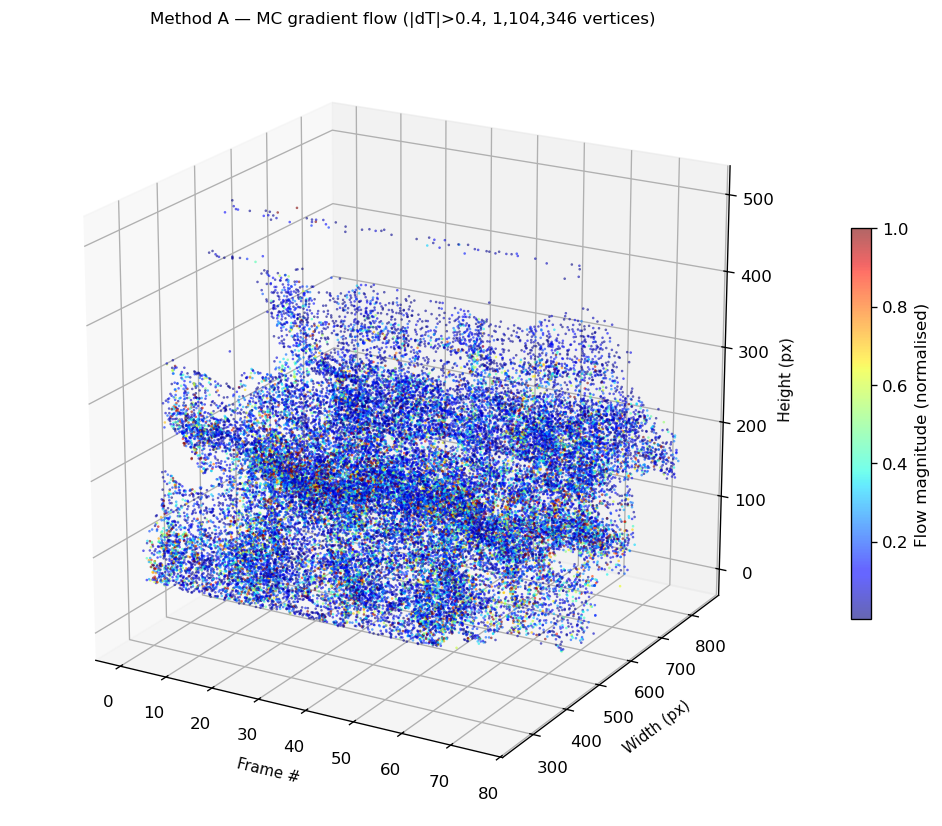

In [76]:
# ── Snapshot A: 3D iso-surface coloured by flow magnitude ─────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Subsample for speed: plot every Nth filtered vertex as a scatter
N_SNAP  = 30            # plot 1 in every 30 vertices (~42k points)
idx_s   = np.arange(0, len(t_filt), N_SNAP)

fig_snap, ax = plt.subplots(figsize=(10, 7),
                             subplot_kw=dict(projection='3d'))
sc = ax.scatter(
    t_filt[idx_s], x_filt[idx_s], y_filt[idx_s],
    c=intensity_filt[idx_s], cmap='jet', s=0.3, alpha=0.6
)
ax.set_xlabel('Frame #', fontsize=9)
ax.set_ylabel('Width (px)', fontsize=9)
ax.set_zlabel('Height (px)', fontsize=9)
ax.set_title(f'Method A — MC gradient flow (|dT|>{DT_THRESHOLD}, {len(t_filt):,} vertices)',
             fontsize=10)
# Match Plotly default view: elev=20, azim=-60
ax.view_init(elev=20, azim=-60)
ax.set_box_aspect([1, 1, 1])
plt.colorbar(sc, ax=ax, label='Flow magnitude (normalised)', shrink=0.5)
plt.tight_layout()
SNAP_A = os.path.join(IMAGES_DIR, 'snap_method_A.png')
plt.savefig(SNAP_A, dpi=120, bbox_inches='tight')
plt.close()
print(f'Snapshot saved: {SNAP_A}')
from IPython.display import Image, display
display(Image(SNAP_A))


## 5 · Method B — Farneback dense optical flow

`cv2.calcOpticalFlowFarneback` models each neighbourhood with a **polynomial expansion**
and minimises a global energy — a dense variant of the Lucas-Kanade window equation:

$$\begin{pmatrix}\sum F_X^2 & \sum F_X F_Y \\ \sum F_X F_Y & \sum F_Y^2\end{pmatrix}
\begin{pmatrix}u\\v\end{pmatrix} =
-\begin{pmatrix}\sum F_X F_T \\ \sum F_Y F_T\end{pmatrix}$$

Output: dense $(u,v)$ vector per pixel per frame pair.

In [77]:
FB_PARAMS = dict(
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0,
)

t0 = time.perf_counter()
fb_magnitudes, fb_angles = [], []

for i in range(n_frames - 1):
    flow = cv2.calcOpticalFlowFarneback(volume_u8[i], volume_u8[i+1], None, **FB_PARAMS)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)
    fb_magnitudes.append(mag.mean())
    fb_angles.append(ang.mean())

fb_time       = time.perf_counter() - t0
fb_magnitudes = np.array(fb_magnitudes)
fb_angles     = np.array(fb_angles)
n_fb_pixels   = (n_frames - 1) * H * W

print("── Method B: Farneback dense flow ────────────────")
print(f"  Frame pairs : {n_frames-1}   Pixels total: {n_fb_pixels:,}")
print(f"  Flow mag    : mean={fb_magnitudes.mean():.4f}  std={fb_magnitudes.std():.4f}")
print(f"  Time        : {fb_time*1000:.2f} ms")

── Method B: Farneback dense flow ────────────────
  Frame pairs : 75   Pixels total: 44,236,800
  Flow mag    : mean=0.8397  std=0.2543
  Time        : 8558.96 ms


### Snapshot — Method B: Farneback flow (first frame)


In [78]:
# ── Snapshot B: Farneback HSV flow overlay on frame 0 ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

if 'fb_flows' in dir() and len(fb_flows) > 0:
    flow0     = fb_flows[0]
    mag0, ang0 = cv2.cartToPolar(flow0[...,0], flow0[...,1], angleInDegrees=True)
    hsv0 = np.zeros((*flow0.shape[:2], 3), dtype=np.uint8)
    hsv0[...,0] = (ang0 / 2).astype(np.uint8)
    hsv0[...,1] = 255
    cap0 = max(float(np.percentile(mag0, 99)), 1e-3)
    hsv0[...,2] = np.clip(mag0 / cap0 * 255, 0, 255).astype(np.uint8)
    hsv0[mag0 < FLOW_THRESHOLD, 2] = 0
    flow_bgr0 = cv2.cvtColor(hsv0, cv2.COLOR_HSV2BGR)
    base0     = cv2.cvtColor(volume_u8[0], cv2.COLOR_GRAY2BGR)
    composite0 = cv2.addWeighted(base0, 0.4, flow_bgr0, 0.6, 0)
    composite0_rgb = cv2.cvtColor(composite0, cv2.COLOR_BGR2RGB)

    fig_snap, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(composite0_rgb)
    ax.set_title(f'Method B — Farneback flow overlay (frame 1, threshold={FLOW_THRESHOLD} px/frame)\n'
                 f'Hue=direction  Value=magnitude  Black=below threshold', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    SNAP_B = os.path.join(IMAGES_DIR, 'snap_method_B.png')
    plt.savefig(SNAP_B, dpi=120, bbox_inches='tight')
    plt.close()
    print(f'Snapshot saved: {SNAP_B}')
    from IPython.display import Image, display
    display(Image(SNAP_B))


## 6 · Method C — Sparse Lucas-Kanade (pyramidal, true LK)

`cv2.calcOpticalFlowPyrLK` tracks **Shi-Tomasi corner features** across frames using
the iterative pyramidal Lucas-Kanade algorithm (Bouguet 2001).  
Unlike Farneback this is truly *sparse*: only detected corners are tracked.  
This is the classic method for **speckle tracking** in echocardiography.

In [79]:
# Shi-Tomasi corner detection parameters
ST_PARAMS = dict(maxCorners=500, qualityLevel=0.01, minDistance=7, blockSize=7)
# Pyramidal LK parameters
LK_PARAMS = dict(winSize=(15, 15), maxLevel=3,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

t0 = time.perf_counter()
lk_magnitudes, lk_angles, lk_n_tracked = [], [], []

for i in range(n_frames - 1):
    prev = volume_u8[i]
    curr = volume_u8[i+1]

    # Detect corners in the previous frame
    p0 = cv2.goodFeaturesToTrack(prev, mask=None, **ST_PARAMS)
    if p0 is None:
        lk_magnitudes.append(0.0)
        lk_angles.append(0.0)
        lk_n_tracked.append(0)
        continue

    # Track corners to next frame
    p1, status, _ = cv2.calcOpticalFlowPyrLK(prev, curr, p0, None, **LK_PARAMS)
    good = status.ravel() == 1
    if good.sum() == 0:
        lk_magnitudes.append(0.0)
        lk_angles.append(0.0)
        lk_n_tracked.append(0)
        continue

    disp  = (p1[good] - p0[good]).squeeze()   # (N, 2): dx, dy per tracked point
    mag   = np.linalg.norm(disp, axis=1)
    angle = np.degrees(np.arctan2(disp[:, 1], disp[:, 0]))
    lk_magnitudes.append(mag.mean())
    lk_angles.append(angle.mean())
    lk_n_tracked.append(good.sum())

lk_time       = time.perf_counter() - t0
lk_magnitudes = np.array(lk_magnitudes)
lk_angles     = np.array(lk_angles)
lk_n_tracked  = np.array(lk_n_tracked)
# Total tracked point-pairs for ns/point metric
n_lk_points   = int(lk_n_tracked.sum())

print("── Method C: Sparse Lucas-Kanade (PyrLK) ─────────")
print(f"  Frame pairs   : {n_frames-1}   Total tracked pts: {n_lk_points:,}")
print(f"  Tracked/frame : mean={lk_n_tracked.mean():.1f}  min={lk_n_tracked.min()}  max={lk_n_tracked.max()}")
print(f"  Flow mag      : mean={lk_magnitudes.mean():.4f}  std={lk_magnitudes.std():.4f}")
print(f"  Time          : {lk_time*1000:.2f} ms")

── Method C: Sparse Lucas-Kanade (PyrLK) ─────────
  Frame pairs   : 75   Total tracked pts: 30,970
  Tracked/frame : mean=412.9  min=325  max=469
  Flow mag      : mean=3.4490  std=1.7429
  Time          : 603.54 ms


### Snapshot — Method C: LK PyrLK arrows (first frame)


In [80]:
# ── Snapshot C: LK PyrLK arrow overlay on frame 0 ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.use('Agg')

if 'lk_tracks' in dir() and len(lk_tracks) > 0:
    p0g0, p1g0 = lk_tracks[0]
    frame_rgb  = cv2.cvtColor(volume_u8[0], cv2.COLOR_GRAY2RGB)

    fig_snap, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(frame_rgb, cmap='gray')

    if p0g0 is not None and len(p0g0) > 0:
        pts0 = p0g0.reshape(-1, 2)
        pts1 = p1g0.reshape(-1, 2)
        disp = pts1 - pts0
        mags = np.linalg.norm(disp, axis=1)
        for pt0, pt1, m in zip(pts0, pts1, mags):
            if m < FLOW_THRESHOLD:
                continue
            ratio = min(m / 10.0, 1.0)
            color = (1.0 - ratio, 0.2, ratio)   # blue→red
            ax.annotate('', xy=pt1, xytext=pt0,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
            ax.plot(*pt0, 'o', color='yellow', ms=2)

    ax.set_title(f'Method C — LK PyrLK arrow overlay (frame 1, threshold={FLOW_THRESHOLD} px/frame)\n'
                 f'Arrows blue→red by speed  Yellow dots=tracked corners', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    SNAP_C = os.path.join(IMAGES_DIR, 'snap_method_C.png')
    plt.savefig(SNAP_C, dpi=120, bbox_inches='tight')
    plt.close()
    print(f'Snapshot saved: {SNAP_C}')
    from IPython.display import Image, display
    display(Image(SNAP_C))


## 7 · Method D — DIS (Dense Inverse Search)

Introduced by Kroeger et al. (2016), **DIS** uses an inverse search strategy over image
patches on a coarse-to-fine pyramid — the fastest dense optical flow in OpenCV, typically
**10-50× faster than Farneback** while remaining competitive in accuracy.  
Preset levels: `PRESET_ULTRAFAST`, `PRESET_FAST` (default), `PRESET_MEDIUM`.

In [81]:
dis = cv2.DISOpticalFlow_create(cv2.DISOpticalFlow_PRESET_FAST)

t0 = time.perf_counter()
dis_magnitudes, dis_angles = [], []

for i in range(n_frames - 1):
    flow = dis.calc(volume_u8[i], volume_u8[i+1], None)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)
    dis_magnitudes.append(mag.mean())
    dis_angles.append(ang.mean())

dis_time       = time.perf_counter() - t0
dis_magnitudes = np.array(dis_magnitudes)
dis_angles     = np.array(dis_angles)
n_dis_pixels   = (n_frames - 1) * H * W

print("── Method D: DIS dense flow ──────────────────────")
print(f"  Frame pairs : {n_frames-1}   Pixels total: {n_dis_pixels:,}")
print(f"  Flow mag    : mean={dis_magnitudes.mean():.4f}  std={dis_magnitudes.std():.4f}")
print(f"  Time        : {dis_time*1000:.2f} ms")

── Method D: DIS dense flow ──────────────────────
  Frame pairs : 75   Pixels total: 44,236,800
  Flow mag    : mean=1.2804  std=0.5794
  Time        : 695.99 ms


### Snapshot — Method D: DIS flow (first frame)


In [82]:
# ── Snapshot D: DIS HSV flow overlay on frame 0 ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

if 'dis_flows' in dir() and len(dis_flows) > 0:
    flow0     = dis_flows[0]
    mag0, ang0 = cv2.cartToPolar(flow0[...,0], flow0[...,1], angleInDegrees=True)
    hsv0 = np.zeros((*flow0.shape[:2], 3), dtype=np.uint8)
    hsv0[...,0] = (ang0 / 2).astype(np.uint8)
    hsv0[...,1] = 255
    cap0 = max(float(np.percentile(mag0, 99)), 1e-3)
    hsv0[...,2] = np.clip(mag0 / cap0 * 255, 0, 255).astype(np.uint8)
    hsv0[mag0 < FLOW_THRESHOLD, 2] = 0
    flow_bgr0 = cv2.cvtColor(hsv0, cv2.COLOR_HSV2BGR)
    base0     = cv2.cvtColor(volume_u8[0], cv2.COLOR_GRAY2BGR)
    composite0 = cv2.addWeighted(base0, 0.4, flow_bgr0, 0.6, 0)
    composite0_rgb = cv2.cvtColor(composite0, cv2.COLOR_BGR2RGB)

    fig_snap, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(composite0_rgb)
    ax.set_title(f'Method D — DIS flow overlay (frame 1, threshold={FLOW_THRESHOLD} px/frame)\n'
                 f'Hue=direction  Value=magnitude  Black=below threshold', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    SNAP_D = os.path.join(IMAGES_DIR, 'snap_method_D.png')
    plt.savefig(SNAP_D, dpi=120, bbox_inches='tight')
    plt.close()
    print(f'Snapshot saved: {SNAP_D}')
    from IPython.display import Image, display
    display(Image(SNAP_D))


## 8 · Method E — RLOF (Robust Local Optical Flow)

Senst et al. (2012–2016). **RLOF** uses an illumination-robust local model with
an M-estimator to suppress outliers — particularly well-suited to echocardiography
where gain artefacts and speckle cause photometric inconsistencies.  
Requires `opencv-contrib-python` (`cv2.optflow` module).  
Here we use the **sparse** variant (`calcOpticalFlowSparseRLOF`) on Shi-Tomasi corners,
falling back gracefully if `optflow` is not installed.

In [83]:
HAS_RLOF = hasattr(cv2, 'optflow') and hasattr(cv2.optflow, 'calcOpticalFlowSparseRLOF')
if not HAS_RLOF:
    print("cv2.optflow not available — install opencv-contrib-python for RLOF.")
    print("Skipping Method E; benchmark will show N/A.")

rlof_magnitudes, rlof_angles, rlof_n_tracked = [], [], []
rlof_time = 0.0
n_rlof_points = 0

if HAS_RLOF:
    rlof_params = cv2.optflow.RLOFOpticalFlowParameter_create()
    rlof_params.setUseInitialFlow(False)

    t0 = time.perf_counter()
    for i in range(n_frames - 1):
        prev_gray = volume_u8[i]
        curr_gray = volume_u8[i+1]
        # RLOF SR_CROSS requires 3-channel; corner detection requires grayscale
        prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
        curr = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)

        p0 = cv2.goodFeaturesToTrack(prev_gray, mask=None, **ST_PARAMS)
        if p0 is None:
            rlof_magnitudes.append(0.0); rlof_angles.append(0.0); rlof_n_tracked.append(0)
            continue

        # OpenCV 4.x: pre-allocate status; returns (p1, status)
        status = np.zeros((len(p0), 1), dtype=np.uint8)
        err    = np.zeros((len(p0), 1), dtype=np.float32)
        p1, status, err = cv2.optflow.calcOpticalFlowSparseRLOF(
            prev, curr, p0, None, status, err, rlof_params
        )
        good = status.ravel() == 1
        if good.sum() == 0:
            rlof_magnitudes.append(0.0); rlof_angles.append(0.0); rlof_n_tracked.append(0)
            continue

        disp  = (p1[good].astype(np.float64) - p0[good].astype(np.float64)).squeeze()
        disp  = np.clip(disp, -20, 20)   # physiological echo limit (~20 px/frame max)
        mag   = np.linalg.norm(disp, axis=1)
        mag   = mag[np.isfinite(mag)]       # drop any residual NaN/Inf
        angle = np.degrees(np.arctan2(disp[:, 1], disp[:, 0]))
        rlof_magnitudes.append(mag.mean())
        rlof_angles.append(angle.mean())
        rlof_n_tracked.append(good.sum())

    rlof_time     = time.perf_counter() - t0
    rlof_magnitudes = np.array(rlof_magnitudes)
    rlof_angles     = np.array(rlof_angles)
    n_rlof_points   = int(np.array(rlof_n_tracked).sum())

    print("── Method E: RLOF sparse flow ────────────────────")
    print(f"  Frame pairs   : {n_frames-1}   Total tracked pts: {n_rlof_points:,}")
    print(f"  Flow mag      : mean={rlof_magnitudes.mean():.4f}  std={rlof_magnitudes.std():.4f}")
    print(f"  Time          : {rlof_time*1000:.2f} ms")

/tmp/ipykernel_30314/567846761.py:38: RuntimeWarning:

invalid value encountered in cast



── Method E: RLOF sparse flow ────────────────────
  Frame pairs   : 75   Total tracked pts: 30,974
  Flow mag      : mean=8.1981  std=12.3082
  Time          : 1785.96 ms


### Snapshot — Method E: RLOF arrows (first frame)


Snapshot saved: /mnt/d/notebooks/RichnessGAN/../images/snap_method_E.png


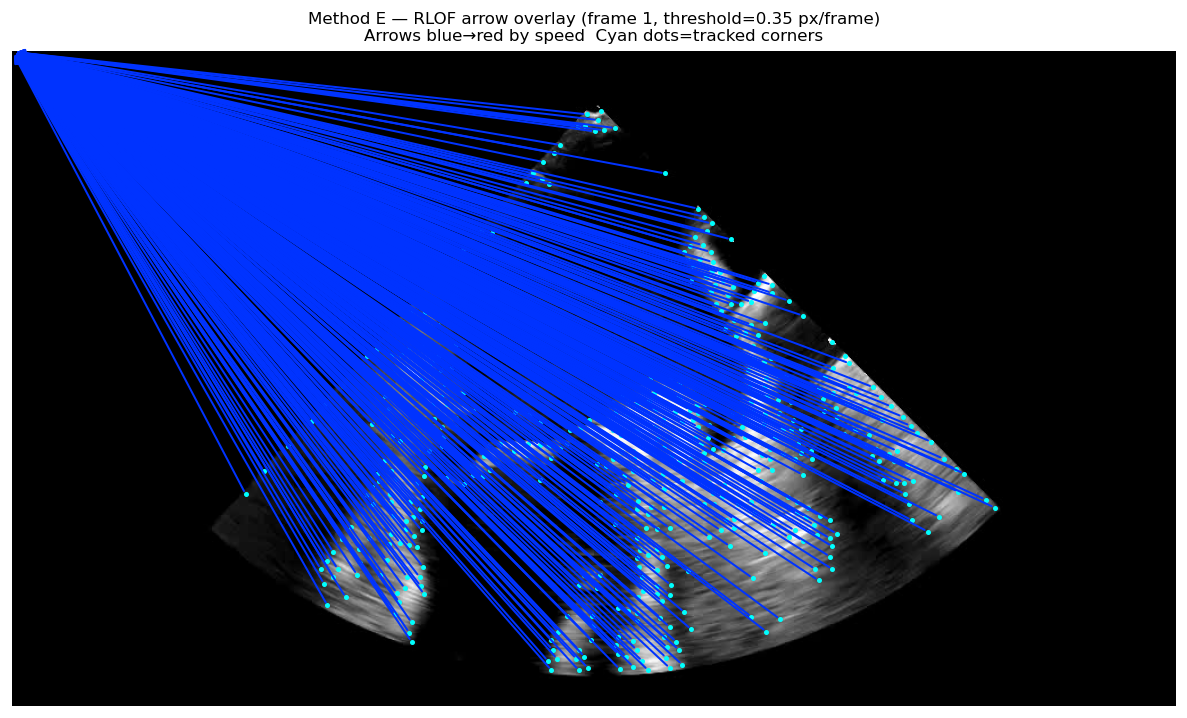

In [84]:
# ── Snapshot E: RLOF arrow overlay on frame 0 ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

if HAS_RLOF and len(rlof_magnitudes) > 0:
    # Re-compute first frame only for snapshot (rlof_tracks not stored — run inline)
    prev_gray0 = volume_u8[0]
    curr_gray0 = volume_u8[1]
    prev_bgr0  = cv2.cvtColor(prev_gray0, cv2.COLOR_GRAY2BGR)
    curr_bgr0  = cv2.cvtColor(curr_gray0, cv2.COLOR_GRAY2BGR)
    p0s0 = cv2.goodFeaturesToTrack(prev_gray0, mask=None, **ST_PARAMS)
    frame_rgb0 = cv2.cvtColor(volume_u8[0], cv2.COLOR_GRAY2RGB)

    fig_snap, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(frame_rgb0)

    if p0s0 is not None:
        st0  = np.zeros((len(p0s0),1), dtype=np.uint8)
        er0  = np.zeros((len(p0s0),1), dtype=np.float32)
        rlof_p = cv2.optflow.RLOFOpticalFlowParameter_create()
        rlof_p.setUseInitialFlow(False)
        p1s0, st0, er0 = cv2.optflow.calcOpticalFlowSparseRLOF(
            prev_bgr0, curr_bgr0, p0s0, None, st0, er0, rlof_p)
        good0 = st0.ravel() == 1
        pts0r = p0s0[good0].reshape(-1,2)
        pts1r = p1s0[good0].reshape(-1,2)
        disp0 = (pts1r.astype(np.float64) - pts0r.astype(np.float64))
        disp0 = np.clip(disp0, -20, 20)
        mags0 = np.linalg.norm(disp0, axis=1)
        for pt0, pt1, m in zip(pts0r, pts1r, mags0):
            if m < FLOW_THRESHOLD:
                continue
            ratio = min(m / 20.0, 1.0)
            color = (1.0 - ratio, 0.2, ratio)
            ax.annotate('', xy=pt1, xytext=pt0,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
            ax.plot(*pt0, 'o', color='cyan', ms=2)

    ax.set_title(f'Method E — RLOF arrow overlay (frame 1, threshold={FLOW_THRESHOLD} px/frame)\n'
                 f'Arrows blue→red by speed  Cyan dots=tracked corners', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    SNAP_E = os.path.join(IMAGES_DIR, 'snap_method_E.png')
    plt.savefig(SNAP_E, dpi=120, bbox_inches='tight')
    plt.close()
    print(f'Snapshot saved: {SNAP_E}')
    from IPython.display import Image, display
    display(Image(SNAP_E))
elif not HAS_RLOF:
    print('RLOF not available — no snapshot generated.')


## 9 · Flow magnitude over time — all methods

In [85]:
frame_idx = np.arange(n_frames - 1)

fig_flow = go.Figure()
# Each trace is added only if the corresponding method cell has been run
if 'fb_magnitudes'   in dir(): fig_flow.add_trace(go.Scatter(x=frame_idx, y=fb_magnitudes,   mode='lines', name='B — Farneback', line=dict(color='royalblue')))
if 'lk_magnitudes'   in dir(): fig_flow.add_trace(go.Scatter(x=frame_idx, y=lk_magnitudes,   mode='lines', name='C — LK sparse', line=dict(color='darkorange')))
if 'dis_magnitudes'  in dir(): fig_flow.add_trace(go.Scatter(x=frame_idx, y=dis_magnitudes,  mode='lines', name='D — DIS',       line=dict(color='green')))
if 'rlof_magnitudes' in dir() and HAS_RLOF: fig_flow.add_trace(go.Scatter(x=frame_idx, y=rlof_magnitudes, mode='lines', name='E — RLOF', line=dict(color='purple')))

# Method A mean as a horizontal reference band
fig_flow.add_hline(y=flow_mag_mc.mean(), line_dash='dash', line_color='crimson',
                   annotation_text='A — MC gradient mean', annotation_position='top left')

fig_flow.update_layout(
    title='Optical flow magnitude over time — all methods',
    xaxis_title='Frame pair #', yaxis_title='Mean flow magnitude (px/frame)',
    height=450, legend=dict(x=0.01, y=0.99),
)
fig_flow.write_html(os.path.join(HTML_DIR, "flow_all_methods.html"))
print(f"Saved to {os.path.join(HTML_DIR,'flow_all_methods.html')}")


Saved to /mnt/d/notebooks/RichnessGAN/../html/flow_all_methods.html


## 10 · Performance benchmark — all 5 methods

Two complementary metrics:
- **Total time (ms)** — wall-clock cost for the full video
- **ns / point** — cost normalised per data point (vertices for A, pixels×frames for dense, tracked points for sparse C/E)

| | Method | Coverage | Illumination robust | Best for |
|---|---|---|---|---|
| A | MC gradient | iso-surface only | inherits MC threshold | Wall motion, structural shape |
| B | Farneback | full dense | moderate | General purpose dense flow |
| C | LK PyrLK sparse | corners only | low | Speckle tracking, landmark motion |
| D | DIS | full dense | moderate | Real-time dense flow |
| E | RLOF | corners (sparse) | **high** (M-estimator) | Artefact-heavy echo, gain variation |

In [86]:
# ── Build results table ────────────────────────────────────────────────────────
def ns_per(t, n): return round(t / n * 1e9, 2) if n > 0 else float('nan')

rows = [
    ('A — MC gradient',  grad_time, n_verts,      flow_mag_mc.mean(),    flow_mag_mc.std()),
    ('B — Farneback',    fb_time,   n_fb_pixels,   fb_magnitudes.mean(),  fb_magnitudes.std()),
    ('C — LK PyrLK',     lk_time,   n_lk_points,   lk_magnitudes.mean(),  lk_magnitudes.std()),
    ('D — DIS',          dis_time,  n_dis_pixels,  dis_magnitudes.mean(), dis_magnitudes.std()),
    ('E — RLOF',
        rlof_time if HAS_RLOF else float('nan'),
        n_rlof_points if HAS_RLOF else 0,
        rlof_magnitudes.mean() if HAS_RLOF else float('nan'),
        rlof_magnitudes.std()  if HAS_RLOF else float('nan'),
    ),
]

df = pd.DataFrame(rows, columns=['Method','Time_s','Data_pts','Flow_mean','Flow_std'])
df['Time_ms']   = (df['Time_s'] * 1000).round(2)
df['ns/point']  = [ns_per(t, n) for t, n in zip(df['Time_s'], df['Data_pts'])]
df['Flow_mean'] = df['Flow_mean'].round(4)
df['Flow_std']  = df['Flow_std'].round(4)
display_df = df[['Method','Time_ms','Data_pts','ns/point','Flow_mean','Flow_std']]
print(display_df.to_string(index=False))

# Fastest by total time (excluding NaN)
valid = df.dropna(subset=['Time_ms'])
winner_total = valid.loc[valid['Time_ms'].idxmin(), 'Method']
winner_ns    = valid.dropna(subset=['ns/point']).loc[valid.dropna(subset=['ns/point'])['ns/point'].idxmin(), 'Method']
print(f"\nFastest total time : {winner_total}")
print(f"Lowest ns/point    : {winner_ns}")

         Method  Time_ms  Data_pts  ns/point  Flow_mean  Flow_std
A — MC gradient    41.32   1392014     29.68     3.3492    5.6045
  B — Farneback  8558.96  44236800    193.48     0.8397    0.2543
   C — LK PyrLK   603.54     30970  19487.91     3.4490    1.7429
        D — DIS   695.99  44236800     15.73     1.2804    0.5794
       E — RLOF  1785.96     30974  57659.87     8.1981   12.3082

Fastest total time : A — MC gradient
Lowest ns/point    : D — DIS


In [87]:
# ── Visual benchmark chart ─────────────────────────────────────────────────────
methods_labels = df['Method'].tolist()
bar_colors = ['crimson','royalblue','darkorange','green','purple']

fig_bench = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Total computation time (ms)', 'Cost per data point (ns)'),
)
fig_bench.add_trace(
    go.Bar(x=methods_labels, y=df['Time_ms'].tolist(),
           marker_color=bar_colors, showlegend=False,
           text=df['Time_ms'].tolist(), textposition='outside'),
    row=1, col=1,
)
fig_bench.add_trace(
    go.Bar(x=methods_labels, y=df['ns/point'].tolist(),
           marker_color=bar_colors, showlegend=False,
           text=[f"{v:.1f}" if not np.isnan(v) else 'N/A' for v in df['ns/point']],
           textposition='outside'),
    row=1, col=2,
)
fig_bench.update_yaxes(title_text='ms', row=1, col=1)
fig_bench.update_yaxes(title_text='ns', row=1, col=2)
fig_bench.update_layout(
    title='Optical flow — 5-method performance comparison',
    height=450,
)
fig_bench.write_html(os.path.join(HTML_DIR, "flow_benchmark.html"))
print(f"Saved to {os.path.join(HTML_DIR,'flow_benchmark.html')}")


Saved to /mnt/d/notebooks/RichnessGAN/../html/flow_benchmark.html


## MOG2/KNN Background Suppression → Marching Cubes → Plotly 3D
Applied to the echocardiography video.
Drop these cells into `EchoGraphy_Time_To_3D_Skimage_To_Plotly.ipynb`
after the main pipeline cells (they reuse `BASE_DIR`, `HTML_DIR`, `IMAGES_DIR`).

**Note on parameters vs vtest.avi:**
- MOG2 on echo produces noisy, speckled masks → lower ISO level (64–127 vs 192 for surveillance)
- Gaussian blur is more important here to suppress speckle before MC
- `learningRate=0.01` slows MOG2 adaptation — useful when the 'background' (chest wall) moves slowly

In [88]:
# ── Background suppression configuration ─────────────────────────────────────
# (BASE_DIR / VIDEO_DIR / HTML_DIR / IMAGES_DIR already defined in cell_config)

BG_VIDEOFILE    = os.path.join(VIDEO_DIR, 'Anonymized_EchoCardiography06.mp4')
BG_ALGO         = 'MOG2'     # 'MOG2' or 'KNN'
BG_MAX_FRAMES   = None       # None = full video
BG_BLUR_K       = 7          # Gaussian blur kernel (larger than vtest — more echo speckle)
BG_LEARNING     = 0.01       # MOG2 learning rate (slow — chest wall moves, not static)
BG_ISO_LEVEL    = 64         # MC threshold on the mask (lower than 192 — echo masks are sparser)
BG_STEP_SIZE    = 1          # MC step size

print(f'Video      : {BG_VIDEOFILE}')
print(f'Algorithm  : {BG_ALGO}  learning_rate={BG_LEARNING}')
print(f'ISO level  : {BG_ISO_LEVEL}  blur={BG_BLUR_K}x{BG_BLUR_K}')

Video      : /mnt/d/notebooks/RichnessGAN/../video/Anonymized_EchoCardiography06.mp4
Algorithm  : MOG2  learning_rate=0.01
ISO level  : 64  blur=7x7


In [89]:
# ── Background subtraction — in-memory, no intermediate file ─────────────────
if BG_ALGO == 'MOG2':
    bg_sub = cv2.createBackgroundSubtractorMOG2()
else:
    bg_sub = cv2.createBackgroundSubtractorKNN()

cap = cv2.VideoCapture(BG_VIDEOFILE)
if not cap.isOpened():
    raise RuntimeError(f'Cannot open: {BG_VIDEOFILE}')

fps_bg  = cap.get(cv2.CAP_PROP_FPS)
nf_tot  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'{nf_tot} frames @ {fps_bg:.1f} fps')

bg_orig_frames = []   # BGR originals for snapshot
bg_mask_frames = []   # uint8 foreground masks
count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Apply background subtractor
    fg = bg_sub.apply(frame, learningRate=BG_LEARNING)

    # Gaussian blur to reduce echo speckle noise
    if BG_BLUR_K > 0:
        fg = cv2.GaussianBlur(fg, (BG_BLUR_K, BG_BLUR_K), 0)

    bg_orig_frames.append(frame.copy())
    bg_mask_frames.append(fg)
    count += 1
    if BG_MAX_FRAMES and count >= BG_MAX_FRAMES:
        break

cap.release()

# Stack → 3D volume (T, H, W)
bg_volume = np.stack(bg_mask_frames).astype(np.float32)
print(f'Frames read  : {len(bg_mask_frames)}')
print(f'Volume shape : {bg_volume.shape}  (T, H, W)')
print(f'Mask range   : {bg_volume.min():.0f} – {bg_volume.max():.0f}')

76 frames @ 20.0 fps
Frames read  : 76
Volume shape : (76, 576, 1024)  (T, H, W)
Mask range   : 0 – 255


In [90]:
# ── Marching Cubes on the foreground mask volume ──────────────────────────────
import time
print(f'Running Marching Cubes (iso={BG_ISO_LEVEL}, step={BG_STEP_SIZE}) ...')
t0 = time.perf_counter()
bg_verts, bg_faces, bg_normals, bg_values = marching_cubes(
    bg_volume,
    level=BG_ISO_LEVEL,
    step_size=BG_STEP_SIZE,
    allow_degenerate=False,
)
bg_mc_time = time.perf_counter() - t0
print(f'Vertices : {bg_verts.shape[0]:,}')
print(f'Faces    : {bg_faces.shape[0]:,}')
print(f'MC time  : {bg_mc_time:.3f} s')

# Coordinate mapping: (T, Y, X)
bg_t = bg_verts[:, 0]
bg_x = bg_verts[:, 2]
bg_y = bg_verts[:, 1].max() - bg_verts[:, 1]   # flip so top = top

Running Marching Cubes (iso=64, step=1) ...
Vertices : 4,165,468
Faces    : 8,312,095
MC time  : 3.175 s


In [91]:
def safe_write_image(fig, path, width=1400, height=900, scale=2, timeout_s=30):
    """Write Plotly figure to PNG with a timeout to prevent kaleido hangs.
    Falls back silently if kaleido is unavailable or times out."""
    import threading, os
    result = {'done': False, 'error': None}
    def _write():
        try:
            fig.write_image(path, width=width, height=height, scale=scale)
            result['done'] = True
        except Exception as e:
            result['error'] = e
    t = threading.Thread(target=_write, daemon=True)
    t.start()
    t.join(timeout=timeout_s)
    if not t.is_alive() and result['done']:
        print(f'Saved PNG  : {path}')
    elif t.is_alive():
        print(f'write_image timed out after {timeout_s}s — skipping PNG (HTML saved)')
    else:
        print(f'write_image skipped ({result["error"]}) — pip install kaleido')

# ── Plotly 3D — save to HTML only (no inline display) ────────────────────────
import plotly.graph_objects as go

fig_bg = go.Figure(data=[
    go.Mesh3d(
        x=bg_t, y=bg_x, z=bg_y,
        colorbar_title='Frame #',
        colorscale=[
            [0.0, 'gold'],
            [0.2, 'mediumturquoise'],
            [1.0, 'magenta'],
        ],
        intensity=bg_t / max(bg_t.max(), 1),
        i=bg_faces[:, 0], j=bg_faces[:, 1], k=bg_faces[:, 2],
        name='echo foreground surface',
        showscale=True, flatshading=False,
    )
])
fig_bg.update_layout(
    title=dict(text=f'Echo background suppression → 3D  ({BG_ALGO}, iso={BG_ISO_LEVEL}) — rotate/zoom freely'),
    scene=dict(
        xaxis=dict(title='Echography Frame #'),
        yaxis=dict(title='Width (px)'),
        zaxis=dict(title='Height (px)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

BG_HTML = os.path.join(HTML_DIR, 'echo_bgsub_3d.html')
fig_bg.write_html(BG_HTML)
print(f'Saved HTML : {BG_HTML}')

try:
    BG_PNG = os.path.join(IMAGES_DIR, 'echo_bgsub_3d.png')
    safe_write_image(fig_bg, BG_PNG, width=1400, height=900, scale=2)
except Exception as e:
    print(f'write_image skipped ({e}) — pip install kaleido')

Saved HTML : /mnt/d/notebooks/RichnessGAN/../html/echo_bgsub_3d.html
write_image timed out after 30s — skipping PNG (HTML saved)


Combined PNG: /mnt/d/notebooks/RichnessGAN/../images/echo_bgsub_combined.png


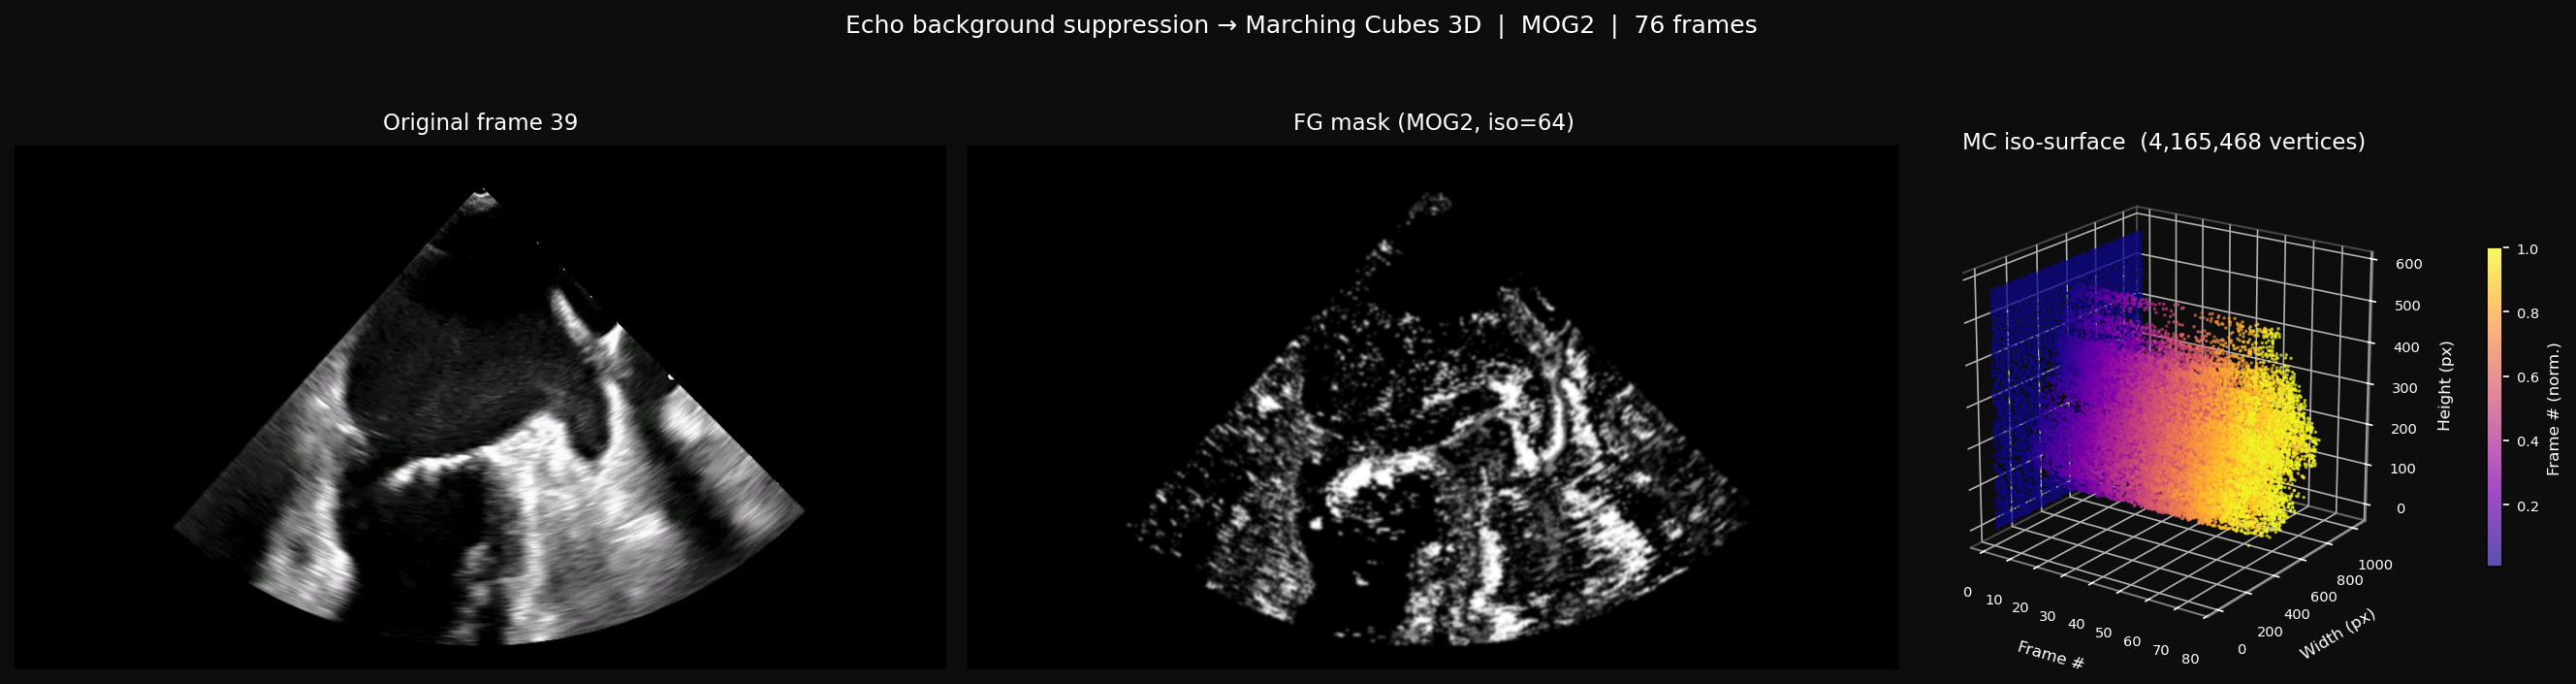

In [92]:
# ── Combined three-panel snapshot: original | mask | 3D scatter ───────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SNAP_IDX = len(bg_orig_frames) // 2   # mid-sequence frame

orig_rgb = cv2.cvtColor(bg_orig_frames[SNAP_IDX], cv2.COLOR_BGR2RGB)
mask_rgb = cv2.cvtColor(bg_mask_frames[SNAP_IDX], cv2.COLOR_GRAY2RGB)

# Subsample vertices for the scatter
N_SCATTER = max(1, len(bg_t) // 40_000)
idx_s = np.arange(0, len(bg_t), N_SCATTER)
intensity_s = bg_t[idx_s] / max(bg_t.max(), 1)

fig_comb, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d0d0d',
                               gridspec_kw={'width_ratios': [1.4, 1.4, 1]})

# Panel 1 — original frame
axes[0].imshow(orig_rgb)
axes[0].set_title(f'Original frame {SNAP_IDX + 1}', color='white', fontsize=11, pad=8)
axes[0].axis('off')

# Panel 2 — foreground mask
axes[1].imshow(mask_rgb)
axes[1].set_title(f'FG mask ({BG_ALGO}, iso={BG_ISO_LEVEL})', color='white', fontsize=11, pad=8)
axes[1].axis('off')

# Panel 3 — 3D scatter (replace axes[2] with a 3D projection)
fig_comb.delaxes(axes[2])
ax3 = fig_comb.add_subplot(1, 3, 3, projection='3d')
ax3.set_facecolor('#0d0d0d')
sc = ax3.scatter(
    bg_t[idx_s], bg_x[idx_s], bg_y[idx_s],
    c=intensity_s, cmap='plasma', s=0.4, alpha=0.7
)
ax3.set_xlabel('Frame #',    color='white', fontsize=8, labelpad=4)
ax3.set_ylabel('Width (px)', color='white', fontsize=8, labelpad=4)
ax3.set_zlabel('Height (px)',color='white', fontsize=8, labelpad=4)
ax3.tick_params(colors='white', labelsize=7)
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
for spine in [ax3.xaxis, ax3.yaxis, ax3.zaxis]:
    spine.line.set_color('grey')
    spine.pane.set_edgecolor('grey')
ax3.view_init(elev=20, azim=-55)
ax3.set_box_aspect([1, 1, 1])
ax3.set_title(f'MC iso-surface  ({bg_verts.shape[0]:,} vertices)',
              color='white', fontsize=11, pad=8)
cbar = fig_comb.colorbar(sc, ax=ax3, shrink=0.5, pad=0.12)
cbar.set_label('Frame # (norm.)', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.suptitle(
    f'Echo background suppression → Marching Cubes 3D  |  {BG_ALGO}  |  {len(bg_mask_frames)} frames',
    color='white', fontsize=12, y=1.01
)
plt.tight_layout()

BG_COMBINED = os.path.join(IMAGES_DIR, 'echo_bgsub_combined.png')
plt.savefig(BG_COMBINED, dpi=150, bbox_inches='tight', facecolor=fig_comb.get_facecolor())
plt.close()
print(f'Combined PNG: {BG_COMBINED}')

from IPython.display import Image, display
display(Image(BG_COMBINED, width=900))